In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, kruskal # kruskal might be useful later, zscore for this task
# For Windrose (if not installed: pip install windrose)
from windrose import WindroseAxes

# Configure plot styles for better visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Default figure size
plt.rcParams['figure.dpi'] = 100 # High resolution for plots

In [2]:
import os
print(os.getcwd())

d:\10academy\phase0\Ai10academy\notebooks


In [3]:
# Path to the raw data file (assuming notebook is in 'notebooks' and data is in 'data')
file_path = '../data/' + 'benin-malanville.csv' # temporarily breaking it up
df_benin = pd.read_csv(file_path)

print("Original DataFrame Info:")
df_benin.info()
print("\nFirst 5 rows of the dataset:")
print(df_benin.head())

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509308 entries, 0 to 509307
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      509308 non-null  object 
 1   GHI            509308 non-null  float64
 2   DNI            509308 non-null  float64
 3   DHI            509308 non-null  float64
 4   ModA           509308 non-null  float64
 5   ModB           509308 non-null  float64
 6   Tamb           509308 non-null  float64
 7   RH             509308 non-null  float64
 8   WS             509308 non-null  float64
 9   WSgust         509308 non-null  float64
 10  WSstdev        509308 non-null  float64
 11  WD             509308 non-null  float64
 12  WDstdev        509308 non-null  float64
 13  BP             509308 non-null  int64  
 14  Cleaning       509308 non-null  int64  
 15  Precipitation  509308 non-null  float64
 16  TModA          509308 non-null  float64
 17  TMod

In [4]:
print("\nDescriptive Statistics for Numeric Columns:")
print(df_benin.describe())


Descriptive Statistics for Numeric Columns:
                 GHI            DNI            DHI           ModA  \
count  509308.000000  509308.000000  509308.000000  509308.000000   
mean      370.599758     164.024184     226.186432     189.764194   
std       201.321728     176.663968     100.521065     281.888942   
min         0.000000       0.000000       0.000000       0.000000   
25%       347.900000     115.300000     225.000000       0.000000   
50%       359.500000     115.300000     225.000000       1.200000   
75%       359.500000     115.300000     225.000000     327.200000   
max      1097.000000     772.300000     590.500000    1105.000000   

                ModB           Tamb             RH             WS  \
count  509308.000000  509308.000000  509308.000000  509308.000000   
mean      181.693908      26.214248      79.747674       1.089871   
std       269.988109       4.397260      20.556188       1.155220   
min         0.000000      12.300000       9.900000       

In [5]:
print("\nMissing Values Report:")
missing_values = df_benin.isnull().sum()
missing_percentage = (missing_values / len(df_benin)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Sort by percentage descending
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print(missing_df)

# List columns with >5% nulls
high_null_cols = missing_df[missing_df['Missing Percentage'] > 5].index.tolist()
if high_null_cols:
    print(f"\nColumns with more than 5% missing values: {high_null_cols}")
else:
    print("\nNo columns with more than 5% missing values.")


Missing Values Report:
          Missing Count  Missing Percentage
Comments         509308               100.0

Columns with more than 5% missing values: ['Comments']



Checking for non-physical values (e.g., negative GHI, DNI, DHI):


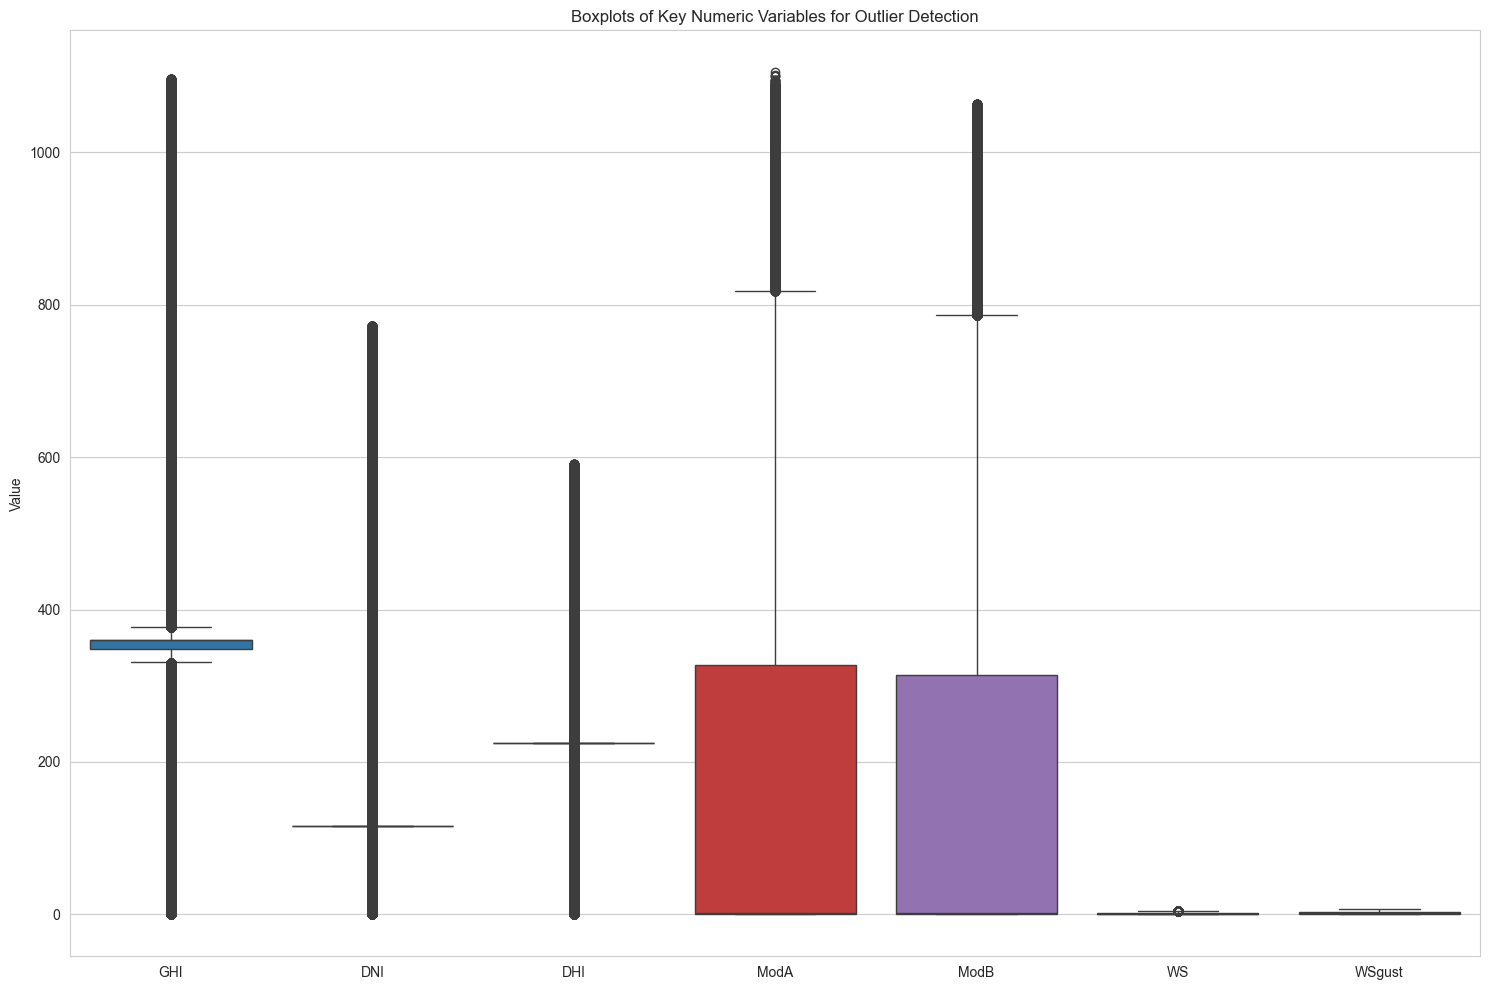

In [6]:
# Convert 'Timestamp' to datetime objects and set as index
df_benin['Timestamp'] = pd.to_datetime(df_benin['Timestamp'])
df_benin = df_benin.set_index('Timestamp')

# Quick check for non-physical values (e.g., negative solar irradiance)
print("\nChecking for non-physical values (e.g., negative GHI, DNI, DHI):")
for col in ['GHI', 'DNI', 'DHI']:
    negative_values = df_benin[df_benin[col] < 0][col].count()
    if negative_values > 0:
        print(f"Column '{col}' has {negative_values} negative values. These should be addressed.")

# Visualize distributions with boxplots for outlier detection
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_benin[['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']])
plt.title('Boxplots of Key Numeric Variables for Outlier Detection')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [7]:
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
df_benin_clean = df_benin.copy() # Work on a copy for cleaning

# Initialize an 'outlier_flag' column to False
df_benin_clean['outlier_flag'] = False

for col in outlier_cols:
    # Calculate Z-scores, handling NaNs
    # Store original values before potential imputation/dropping for cleaning impact analysis
    df_benin_clean[f'{col}_original'] = df_benin_clean[col]
    
    # Only calculate z-score for non-null values
    valid_data = df_benin_clean[col].dropna()
    if not valid_data.empty:
        z_scores = np.abs(zscore(valid_data))
        # Get the indices of outliers in the valid_data series
        outlier_indices = valid_data[z_scores > 3].index
        # Flag these rows in the main DataFrame
        df_benin_clean.loc[outlier_indices, 'outlier_flag'] = True
        print(f"Found {len(outlier_indices)} outliers in '{col}' (Z-score > 3).")
    else:
        print(f"Column '{col}' is entirely NaN, skipping Z-score calculation.")

total_flagged_outliers = df_benin_clean['outlier_flag'].sum()
print(f"\nTotal rows flagged as outliers across specified columns: {total_flagged_outliers}")

Found 3758 outliers in 'GHI' (Z-score > 3).
Found 9162 outliers in 'DNI' (Z-score > 3).
Found 4980 outliers in 'DHI' (Z-score > 3).
Found 694 outliers in 'ModA' (Z-score > 3).
Found 1089 outliers in 'ModB' (Z-score > 3).
Found 1394 outliers in 'WS' (Z-score > 3).
Found 1370 outliers in 'WSgust' (Z-score > 3).

Total rows flagged as outliers across specified columns: 18511


In [8]:
# Handle negative solar irradiance values: set to 0 or NaN, then impute
for col in ['GHI', 'DNI', 'DHI']:
    df_benin_clean.loc[df_benin_clean[col] < 0, col] = np.nan # Convert negatives to NaN

# Impute missing values for key continuous variables with their median
impute_cols = ['GHI', 'DNI', 'DHI', 'Tamb', 'RH', 'BP', 'WS', 'WSgust', 'WD', 'ModA', 'ModB']
for col in impute_cols:
    if df_benin_clean[col].isnull().any():
        median_val = df_benin_clean[col].median()
        df_benin_clean[col].fillna(median_val, inplace=True)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

# Drop rows flagged as outliers
initial_rows = len(df_benin_clean)
df_benin_clean = df_benin_clean[~df_benin_clean['outlier_flag']].copy() # Keep only non-outlier rows
rows_after_outlier_drop = len(df_benin_clean)
print(f"\nDropped {initial_rows - rows_after_outlier_drop} rows flagged as outliers.")

# Drop the temporary '_original' and 'outlier_flag' columns if no longer needed
df_benin_clean.drop(columns=[col for col in df_benin_clean.columns if '_original' in col or 'outlier_flag' in col], inplace=True, errors='ignore')

print("\nDataFrame after cleaning:")
df_benin_clean.info()


Dropped 18511 rows flagged as outliers.

DataFrame after cleaning:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 490797 entries, 2021-10-30 00:01:00 to 2022-10-30 00:00:00
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   GHI            490797 non-null  float64
 1   DNI            490797 non-null  float64
 2   DHI            490797 non-null  float64
 3   ModA           490797 non-null  float64
 4   ModB           490797 non-null  float64
 5   Tamb           490797 non-null  float64
 6   RH             490797 non-null  float64
 7   WS             490797 non-null  float64
 8   WSgust         490797 non-null  float64
 9   WSstdev        490797 non-null  float64
 10  WD             490797 non-null  float64
 11  WDstdev        490797 non-null  float64
 12  BP             490797 non-null  int64  
 13  Cleaning       490797 non-null  int64  
 14  Precipitation  490797 non-null  float64
 15  TModA          49

In [9]:
output_path = '../data/benin_clean.csv'
df_benin_clean.to_csv(output_path, index=True) # index=True to save Timestamp as a column
print(f"\nCleaned data exported to {output_path}")


Cleaned data exported to ../data/benin_clean.csv


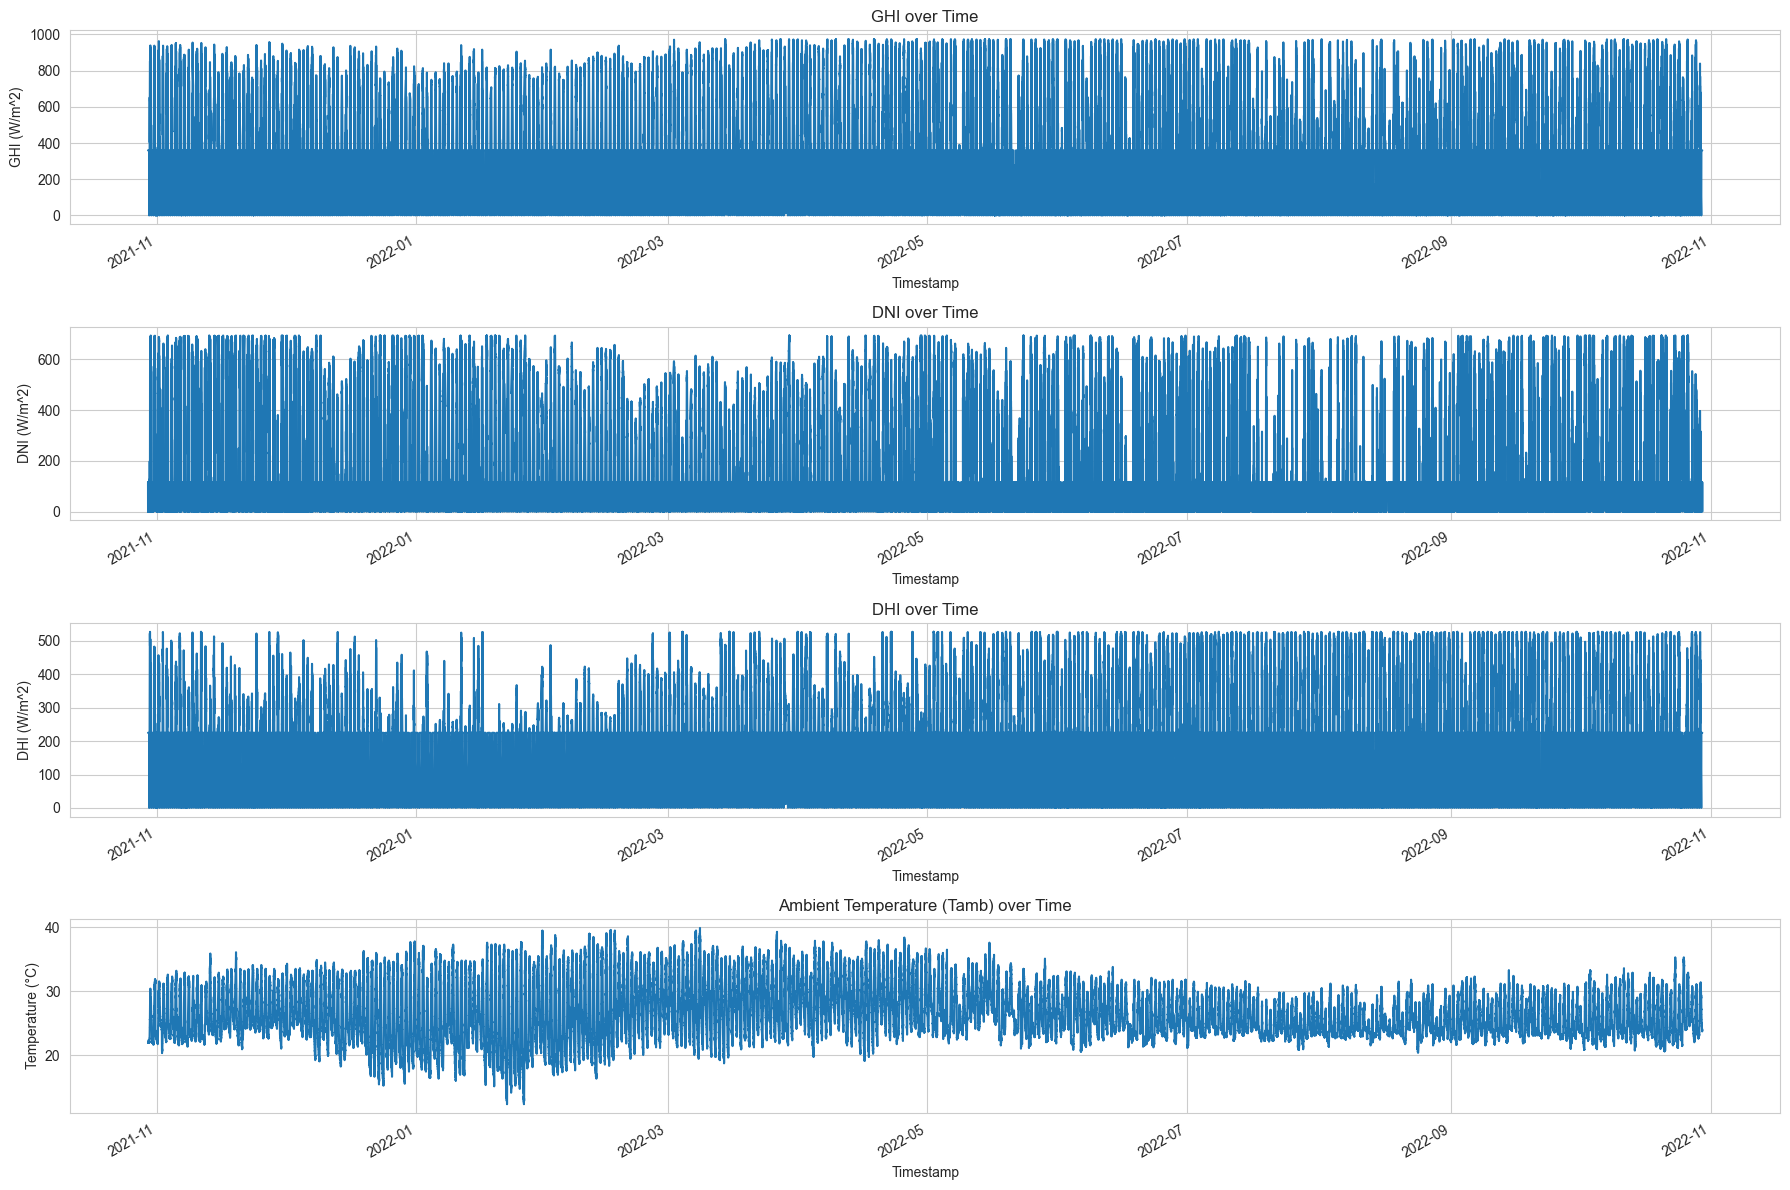

In [10]:
plt.figure(figsize=(18, 12))

plt.subplot(4, 1, 1)
df_benin_clean['GHI'].plot(title='GHI over Time')
plt.ylabel('GHI (W/m^2)')

plt.subplot(4, 1, 2)
df_benin_clean['DNI'].plot(title='DNI over Time')
plt.ylabel('DNI (W/m^2)')

plt.subplot(4, 1, 3)
df_benin_clean['DHI'].plot(title='DHI over Time')
plt.ylabel('DHI (W/m^2)')

plt.subplot(4, 1, 4)
df_benin_clean['Tamb'].plot(title='Ambient Temperature (Tamb) over Time')
plt.ylabel('Temperature (°C)')
plt.xlabel('Timestamp')

plt.tight_layout()
plt.show()

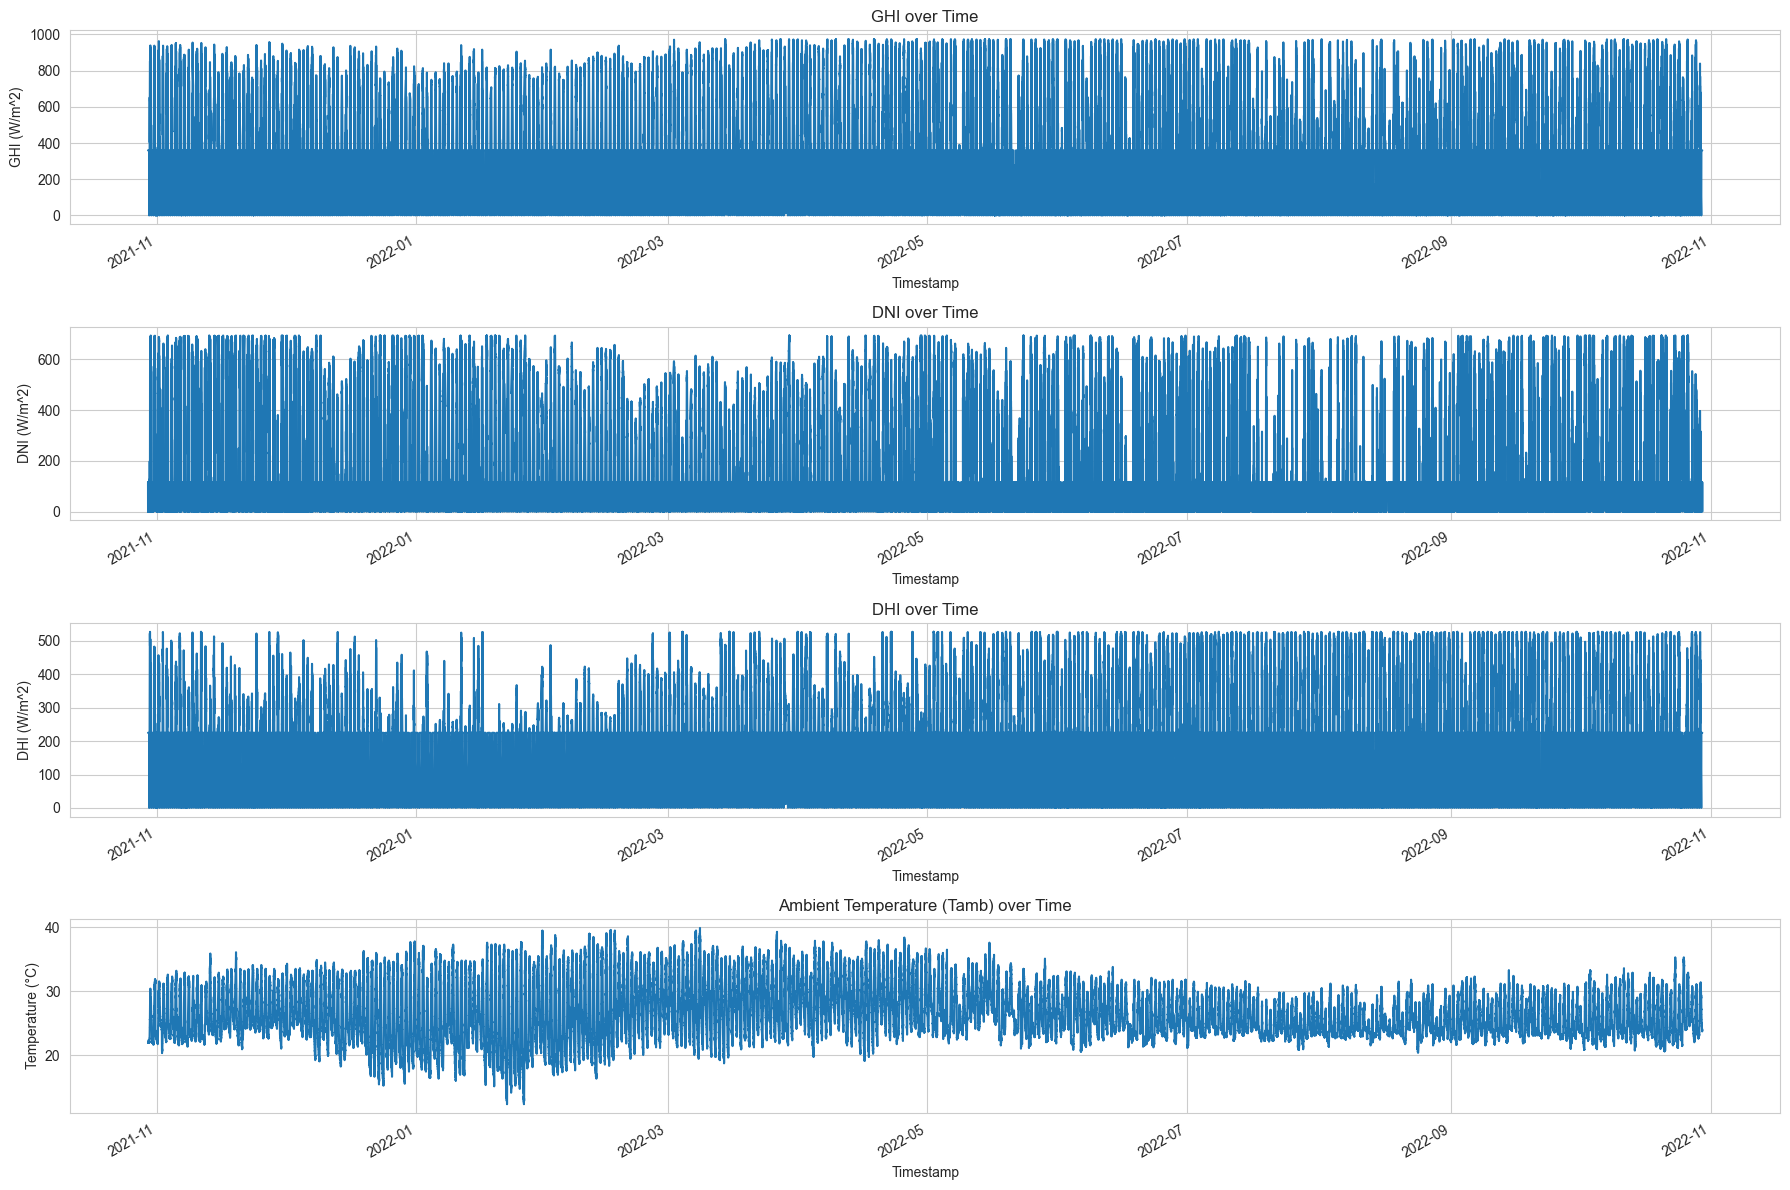

In [11]:
plt.figure(figsize=(18, 12))

plt.subplot(4, 1, 1)
df_benin_clean['GHI'].plot(title='GHI over Time')
plt.ylabel('GHI (W/m^2)')

plt.subplot(4, 1, 2)
df_benin_clean['DNI'].plot(title='DNI over Time')
plt.ylabel('DNI (W/m^2)')

plt.subplot(4, 1, 3)
df_benin_clean['DHI'].plot(title='DHI over Time')
plt.ylabel('DHI (W/m^2)')

plt.subplot(4, 1, 4)
df_benin_clean['Tamb'].plot(title='Ambient Temperature (Tamb) over Time')
plt.ylabel('Temperature (°C)')
plt.xlabel('Timestamp')

plt.tight_layout()
plt.show()

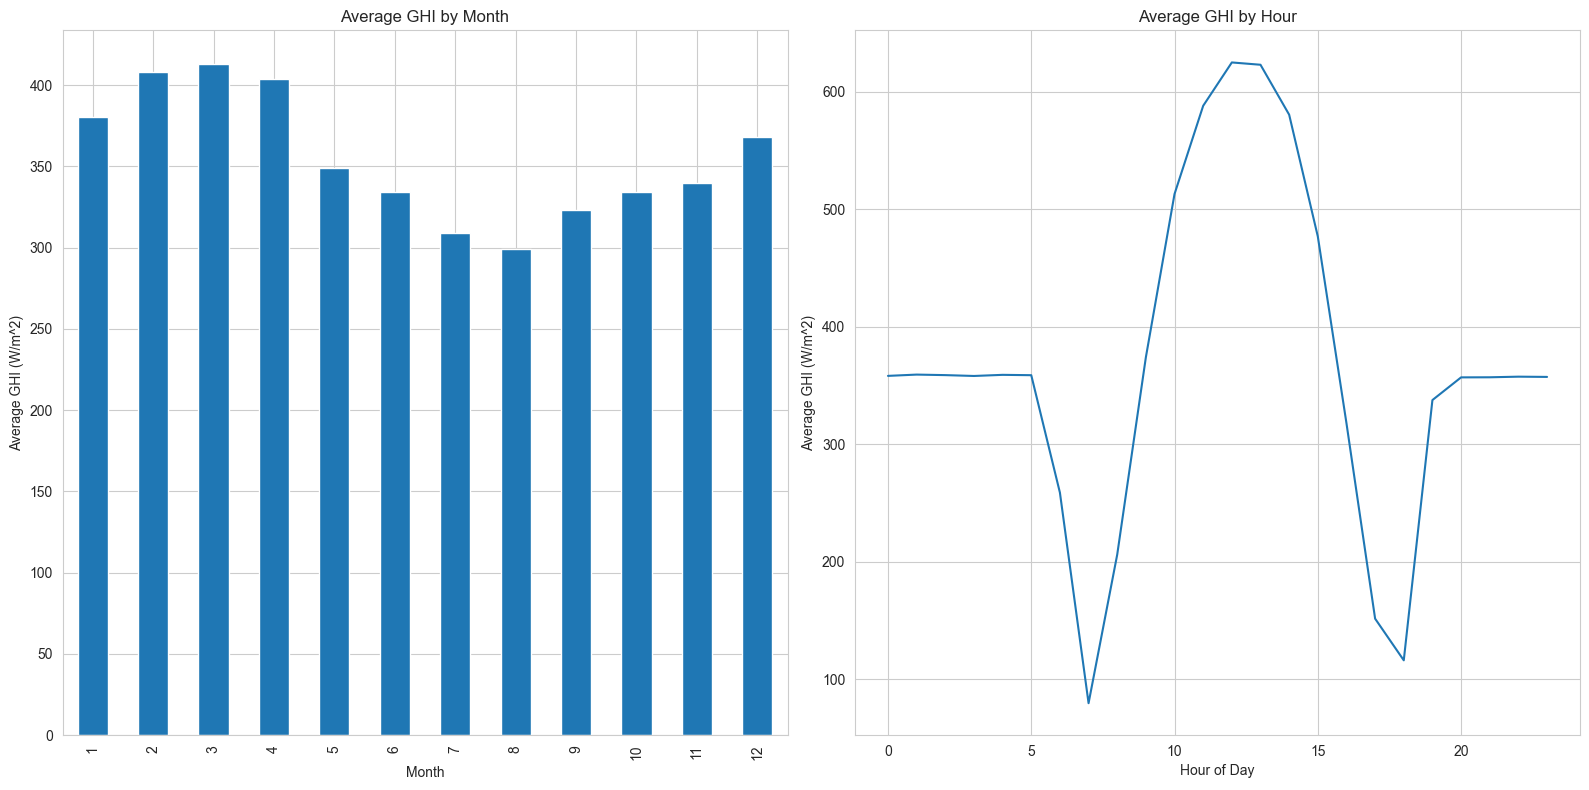

In [12]:
# Extract month and hour for pattern analysis
df_benin_clean['Month'] = df_benin_clean.index.month
df_benin_clean['Hour'] = df_benin_clean.index.hour

plt.figure(figsize=(16, 8))

# Monthly average GHI
plt.subplot(1, 2, 1)
df_benin_clean.groupby('Month')['GHI'].mean().plot(kind='bar')
plt.title('Average GHI by Month')
plt.xlabel('Month')
plt.ylabel('Average GHI (W/m^2)')

# Hourly average GHI
plt.subplot(1, 2, 2)
df_benin_clean.groupby('Hour')['GHI'].mean().plot(kind='line')
plt.title('Average GHI by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average GHI (W/m^2)')

plt.tight_layout()
plt.show()

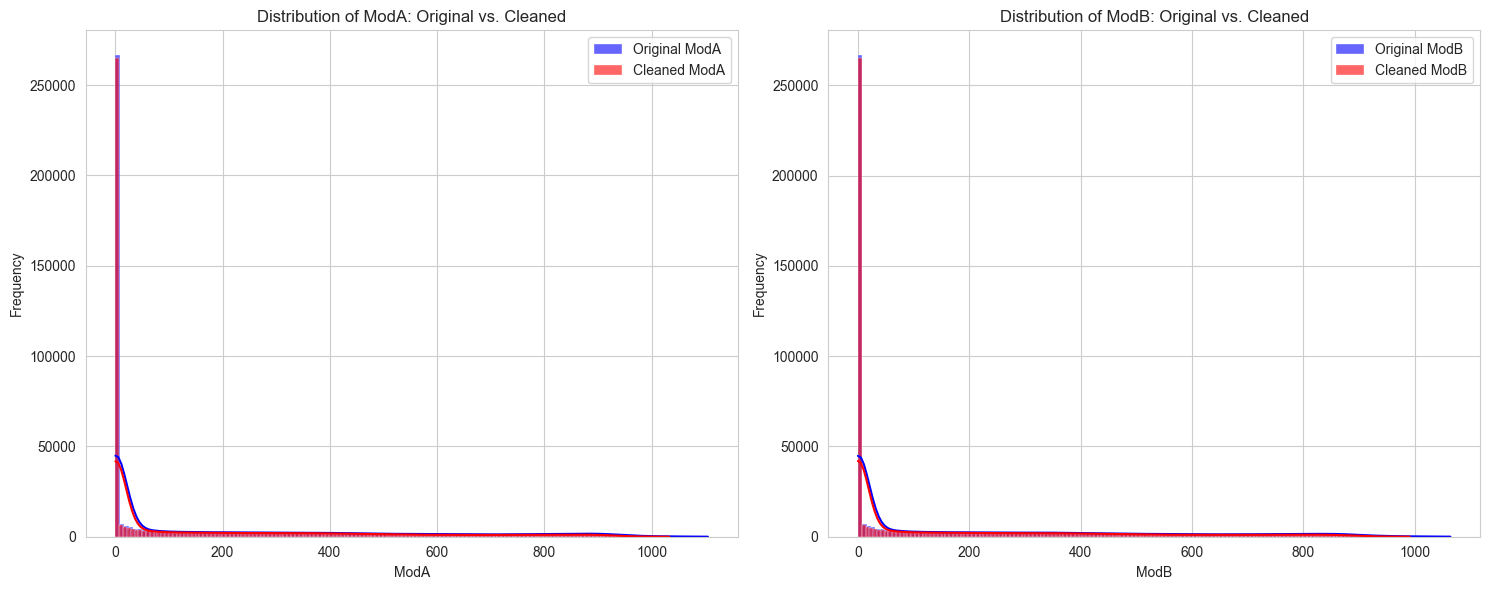


Summary Statistics for ModA (Original vs. Cleaned):
Original ModA:
 count    509308.000000
mean        189.764194
std         281.888942
min           0.000000
25%           0.000000
50%           1.200000
75%         327.200000
max        1105.000000
Name: ModA, dtype: float64

Cleaned ModA:
 count    490797.000000
mean        168.436684
std         259.907803
min           0.000000
25%           0.000000
50%           0.100000
75%         282.700000
max        1033.000000
Name: ModA, dtype: float64

Summary Statistics for ModB (Original vs. Cleaned):
Original ModB:
 count    509308.000000
mean        181.693908
std         269.988109
min           0.000000
25%           0.000000
50%           1.100000
75%         314.500000
max        1064.000000
Name: ModB, dtype: float64

Cleaned ModB:
 count    490797.000000
mean        161.064725
std         248.390150
min           0.000000
25%           0.000000
50%           0.100000
75%         271.300000
max         991.000000
Name: ModB, d

In [13]:
# Re-load original data for comparison (or use the original df_benin before cleaning)
df_original_mod = pd.read_csv(file_path, parse_dates=['Timestamp']).set_index('Timestamp')

plt.figure(figsize=(15, 6))

# ModA comparison
plt.subplot(1, 2, 1)
sns.histplot(df_original_mod['ModA'].dropna(), color='blue', label='Original ModA', kde=True, alpha=0.6)
sns.histplot(df_benin_clean['ModA'], color='red', label='Cleaned ModA', kde=True, alpha=0.6)
plt.title('Distribution of ModA: Original vs. Cleaned')
plt.xlabel('ModA')
plt.ylabel('Frequency')
plt.legend()

# ModB comparison
plt.subplot(1, 2, 2)
sns.histplot(df_original_mod['ModB'].dropna(), color='blue', label='Original ModB', kde=True, alpha=0.6)
sns.histplot(df_benin_clean['ModB'], color='red', label='Cleaned ModB', kde=True, alpha=0.6)
plt.title('Distribution of ModB: Original vs. Cleaned')
plt.xlabel('ModB')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# You can also look at summary statistics before/after for ModA and ModB
print("\nSummary Statistics for ModA (Original vs. Cleaned):")
print("Original ModA:\n", df_original_mod['ModA'].describe())
print("\nCleaned ModA:\n", df_benin_clean['ModA'].describe())

print("\nSummary Statistics for ModB (Original vs. Cleaned):")
print("Original ModB:\n", df_original_mod['ModB'].describe())
print("\nCleaned ModB:\n", df_benin_clean['ModB'].describe())

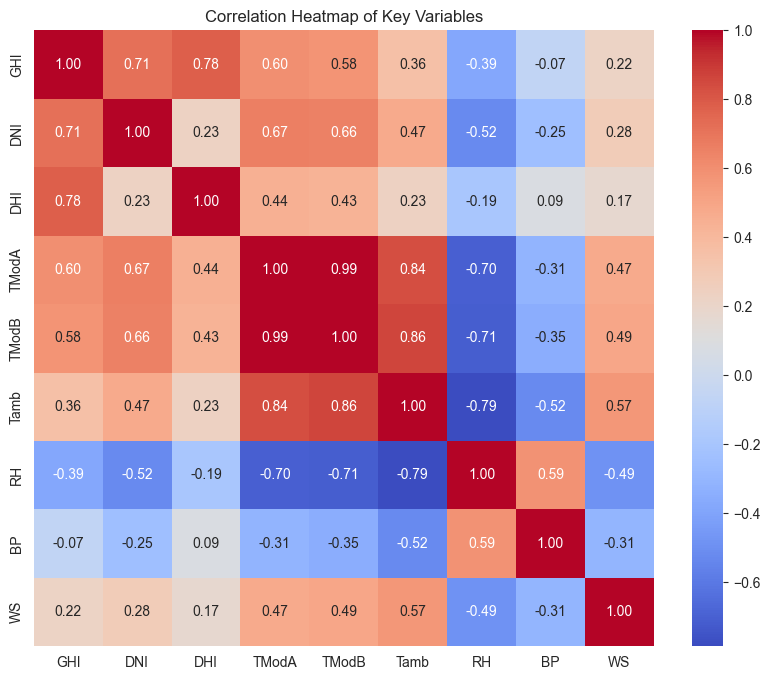

In [14]:
correlation_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'BP', 'WS'] # Added more for richer insights
corr_matrix = df_benin_clean[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Variables')
plt.show()

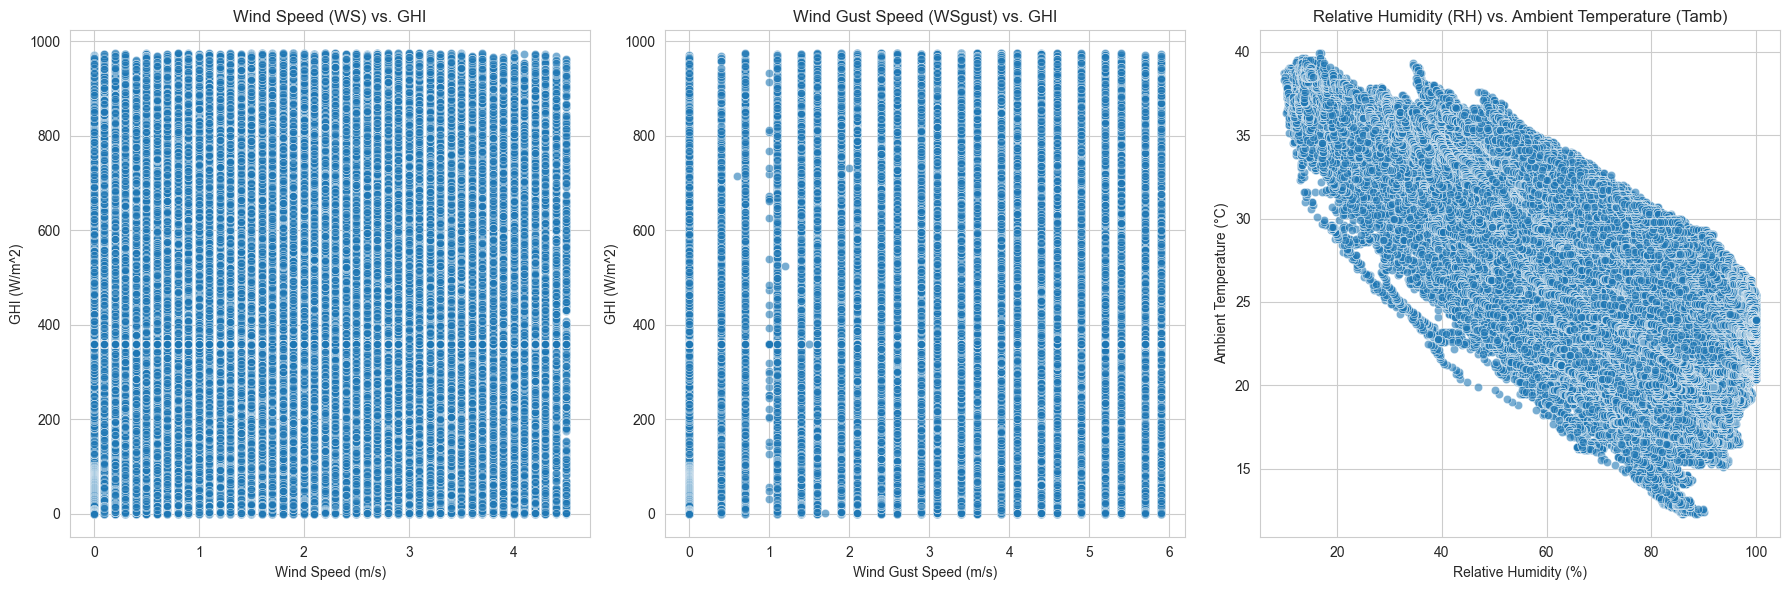

In [15]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='WS', y='GHI', data=df_benin_clean, alpha=0.6)
plt.title('Wind Speed (WS) vs. GHI')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('GHI (W/m^2)')

plt.subplot(1, 3, 2)
sns.scatterplot(x='WSgust', y='GHI', data=df_benin_clean, alpha=0.6)
plt.title('Wind Gust Speed (WSgust) vs. GHI')
plt.xlabel('Wind Gust Speed (m/s)')
plt.ylabel('GHI (W/m^2)')

plt.subplot(1, 3, 3)
sns.scatterplot(x='RH', y='Tamb', data=df_benin_clean, alpha=0.6)
plt.title('Relative Humidity (RH) vs. Ambient Temperature (Tamb)')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Ambient Temperature (°C)')

plt.tight_layout()
plt.show()

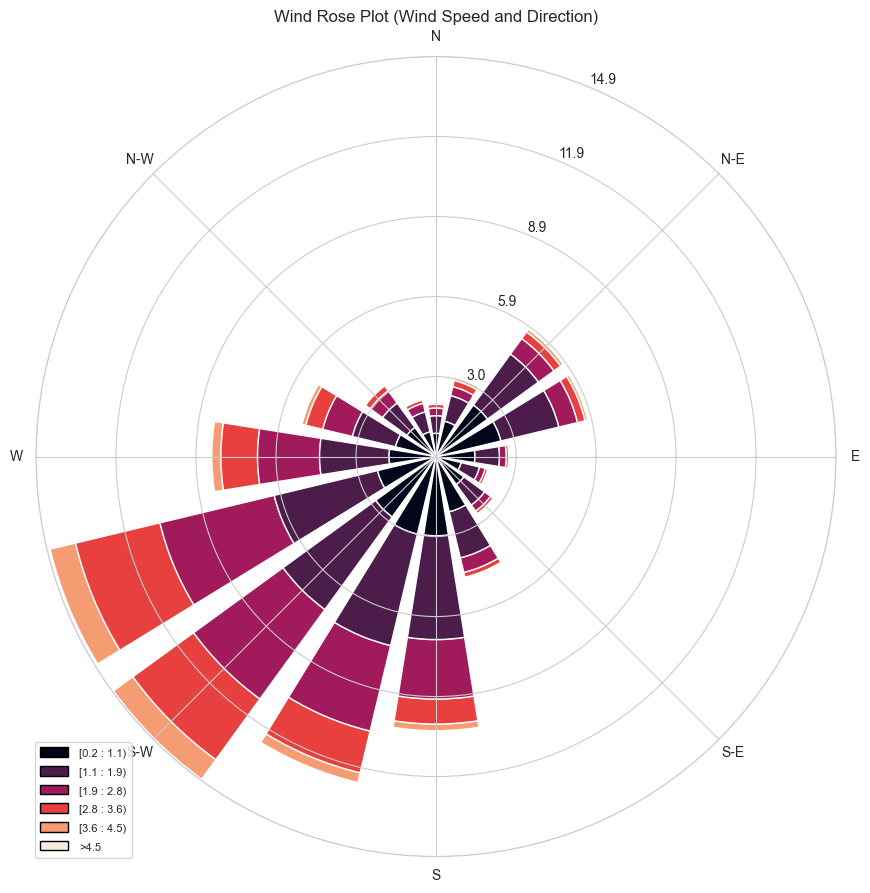

In [16]:
# Ensure WindroseAxes is imported and WS, WD are numeric
# Filter out zero wind speeds for clearer visualization in windrose
df_wind = df_benin_clean[(df_benin_clean['WS'] > 0.1) & (df_benin_clean['WD'].notna())].copy()

if not df_wind.empty:
    fig = plt.figure(figsize=(10, 10))
    ax = WindroseAxes.from_ax(fig=fig)
    ax.bar(df_wind['WD'], df_wind['WS'], normed=True, opening=0.8, edgecolor='white')
    ax.set_legend()
    plt.title('Wind Rose Plot (Wind Speed and Direction)')
    plt.show()
else:
    print("Not enough wind data with speed > 0.1 to plot wind rose.")

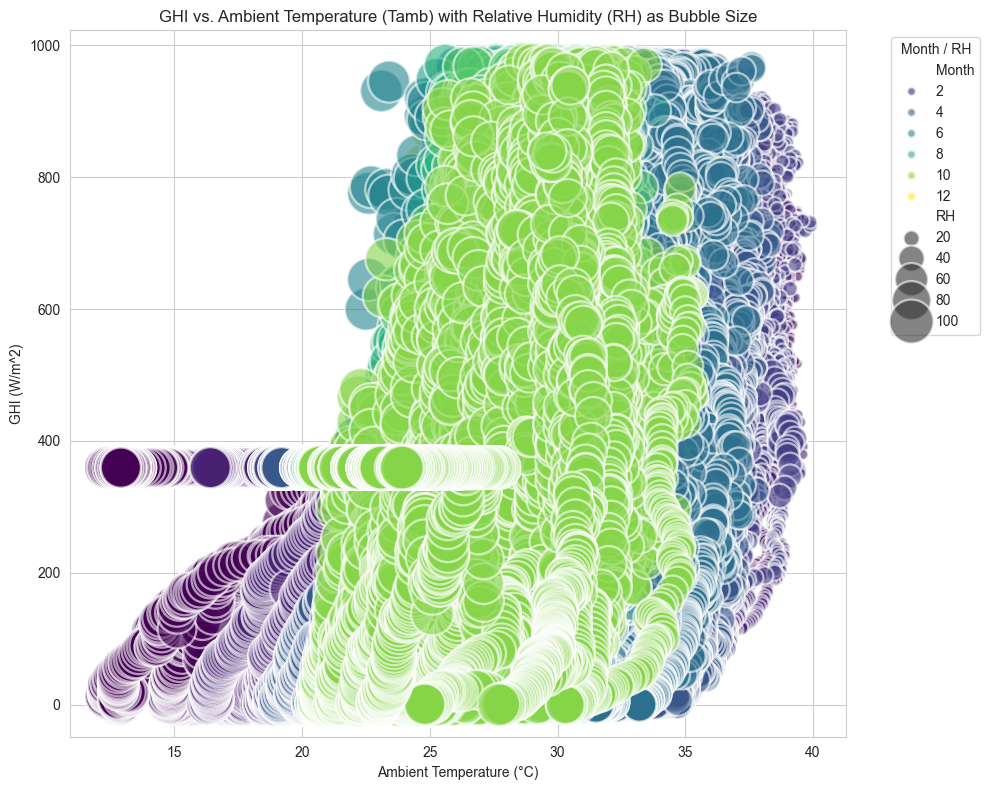

In [17]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Tamb',
    y='GHI',
    size='RH',       # Bubble size determined by Relative Humidity
    data=df_benin_clean,
    hue='Month',     # Optional: color by month for seasonal insight
    sizes=(20, 1000), # Min and max size of bubbles
    alpha=0.6,
    palette='viridis'
)
plt.title('GHI vs. Ambient Temperature (Tamb) with Relative Humidity (RH) as Bubble Size')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('GHI (W/m^2)')
plt.legend(title='Month / RH', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()